# RAG Configuration Experiments
**Hooria Zahoor — AI Summer Internship 2026**

This notebook reproduces all experiments from the findings report:
1. Chunk Size comparison
2. Chunk Overlap comparison
3. Prompt Templates (rubric, no live LLM call needed)
4. Embedding Models (TF-IDF vs LSA)

**Requirements:** `numpy`, `scikit-learn`, `matplotlib` (no GPU/torch needed)
```
pip install numpy scikit-learn matplotlib
```


## 1. Test Corpus & Queries
Synthetic enterprise documents (HR, IT Security, Finance policies) + 10 test questions with known ground-truth keywords.

In [1]:
"""
Synthetic enterprise document corpus + test query set with ground-truth answer keywords.
Used consistently across all four experiments so results are comparable.
"""

DOCUMENTS = {
"HR_Policy.txt": """
Employee Leave Policy. All full-time employees are entitled to 21 days of annual paid leave per calendar year, accrued monthly at a rate of 1.75 days. Unused annual leave may be carried forward to the following year up to a maximum of 10 days; any balance beyond this cap is forfeited on December 31st. Employees must submit leave requests through the HR portal at least 5 working days in advance for planned leave. Sick leave is separate from annual leave and totals 12 days per year, with a medical certificate required for absences exceeding 3 consecutive days.

Maternity and Paternity Leave. Female employees are entitled to 90 calendar days of fully paid maternity leave, which may begin up to 2 weeks before the expected delivery date. Male employees are entitled to 10 working days of paid paternity leave, to be taken within 30 days of the child's birth. Extended unpaid parental leave of up to 6 months may be requested and is subject to manager approval and business needs.

Remote Work Policy. Employees may work remotely up to 2 days per week with prior manager approval. Fully remote arrangements require Director-level sign-off and are reviewed quarterly. Remote employees must remain reachable during core hours of 10 AM to 4 PM local time and attend all mandatory virtual meetings with video enabled.

Performance Reviews. Formal performance reviews are conducted twice a year, in June and December. Ratings range from 1 (needs improvement) to 5 (outstanding) across four dimensions: technical delivery, collaboration, initiative, and communication. Employees rated below 3 for two consecutive cycles are placed on a 90-day Performance Improvement Plan (PIP) with weekly check-ins from their manager and HR.

Code of Conduct. Employees are expected to treat colleagues, clients, and vendors with respect and professionalism at all times. Harassment, discrimination, or retaliation of any kind will not be tolerated and may result in immediate termination. All conflicts of interest, including outside employment or financial interests in vendors, must be disclosed to HR within 30 days of arising.
""",

"IT_Security_Policy.txt": """
Password Requirements. All employees must use passwords of at least 14 characters, combining uppercase, lowercase, numbers, and symbols. Passwords must be rotated every 90 days and may not reuse any of the previous 10 passwords. Multi-factor authentication (MFA) is mandatory for all systems handling client data, email, and VPN access.

Data Classification. Company data is classified into four levels: Public, Internal, Confidential, and Restricted. Restricted data, including client PII and payment details, must be encrypted at rest and in transit using AES-256, accessed only from managed company devices, and must never be stored on personal cloud drives, USB drives, or removable media of any kind.

Incident Response. Any suspected security incident, including phishing emails, lost devices, or unauthorized access, must be reported to the Security Team within 1 hour of discovery via the #security-incidents Slack channel or the 24/7 hotline. The Security Team conducts a post-incident review for all Critical or High severity incidents within 5 business days, publishing a summary of root cause and remediation steps to affected teams.

Access Control. System access follows the principle of least privilege: employees are granted only the permissions required for their current role. Access reviews are conducted quarterly by system owners, and any access not used in the past 90 days is automatically revoked. Privileged/admin access requires a documented business justification and Director approval, renewed every 6 months.

Data Retention. Client data is retained for a maximum of 7 years after contract termination, after which it is securely deleted using NIST-compliant erasure methods. Internal communications and logs are retained for 2 years for audit purposes. Employees must not retain confidential client data on local drives beyond the duration of an active project.
""",

"Finance_Expense_Policy.txt": """
Travel Expense Reimbursement. Employees traveling for business must book flights and hotels through the approved corporate travel portal. Economy class is standard for flights under 6 hours; business class requires VP approval. Hotel spend is capped at $220 per night in major metro cities and $150 per night elsewhere, unless a conference venue requires otherwise.

Meal and Entertainment Expenses. Daily meal allowance while traveling is $75, itemized receipts are required for any single expense over $25. Client entertainment expenses require pre-approval from a manager and must include the client's name and business purpose in the expense report. Alcohol reimbursement is capped at $40 per event and must comply with local regulations.

Expense Submission Deadlines. All expense reports must be submitted within 30 days of the expense being incurred through the finance system. Reports submitted after 60 days require Finance Director approval and may be denied at the company's discretion. Reimbursements are processed within 10 business days of report approval, paid via direct deposit.

Procurement and Purchase Orders. Any purchase over $1,000 requires a Purchase Order (PO) approved by the relevant department head before the order is placed. Purchases over $10,000 require two approvals: department head and Finance. Software subscriptions must be routed through IT for security review regardless of cost, to ensure compliance with the Data Classification policy.

Corporate Credit Cards. Corporate cards are issued to employees who travel frequently or manage vendor relationships, subject to Finance approval. Cardholders must reconcile transactions monthly in the expense system; cards with two consecutive months of unreconciled transactions will be suspended until resolved.
""",
}

# Test queries with ground-truth keywords that MUST appear in a correctly-retrieved chunk.
# Each query maps to the source document and the key fact expected in the top result.
TEST_QUERIES = [
    {"query": "How many days of annual leave do employees get?", "doc": "HR_Policy.txt", "keywords": ["21 days", "annual"]},
    {"query": "How long is maternity leave?", "doc": "HR_Policy.txt", "keywords": ["90 calendar days", "maternity"]},
    {"query": "How many remote work days are allowed per week?", "doc": "HR_Policy.txt", "keywords": ["2 days per week", "remote"]},
    {"query": "When are performance reviews conducted?", "doc": "HR_Policy.txt", "keywords": ["June", "December", "performance review"]},
    {"query": "What is the minimum password length required?", "doc": "IT_Security_Policy.txt", "keywords": ["14 characters", "password"]},
    {"query": "How quickly must a security incident be reported?", "doc": "IT_Security_Policy.txt", "keywords": ["1 hour", "incident"]},
    {"query": "How long is client data retained after contract ends?", "doc": "IT_Security_Policy.txt", "keywords": ["7 years", "retained"]},
    {"query": "What is the daily meal allowance while traveling?", "doc": "Finance_Expense_Policy.txt", "keywords": ["$75", "meal allowance"]},
    {"query": "When do expense reports need to be submitted?", "doc": "Finance_Expense_Policy.txt", "keywords": ["30 days", "expense report"]},
    {"query": "What purchase amount requires a Purchase Order?", "doc": "Finance_Expense_Policy.txt", "keywords": ["$1,000", "Purchase Order"]},
]

# Harder queries that deliberately avoid the document's exact vocabulary (synonyms/paraphrases).
# Designed to test semantic generalization — the classic strength of dense embeddings over
# exact term-matching sparse methods like TF-IDF.
HARD_QUERIES = [
    {"query": "How much time off do new mothers get after having a baby?", "doc": "HR_Policy.txt", "keywords": ["90 calendar days", "maternity"]},
    {"query": "Can staff log in from home instead of the office?", "doc": "HR_Policy.txt", "keywords": ["2 days per week", "remote"]},
    {"query": "How complex does my login credential need to be?", "doc": "IT_Security_Policy.txt", "keywords": ["14 characters", "password"]},
    {"query": "How fast do I need to alert the team about a breach?", "doc": "IT_Security_Policy.txt", "keywords": ["1 hour", "incident"]},
    {"query": "What's the cap on daily food costs on a business trip?", "doc": "Finance_Expense_Policy.txt", "keywords": ["$75", "meal allowance"]},
    {"query": "What spending amount triggers the need for formal purchasing approval?", "doc": "Finance_Expense_Policy.txt", "keywords": ["$1,000", "Purchase Order"]},
]

if __name__ == "__main__":
    total_chars = sum(len(v) for v in DOCUMENTS.values())
    print(f"{len(DOCUMENTS)} documents, {total_chars} total characters, {len(TEST_QUERIES)} test queries, {len(HARD_QUERIES)} hard paraphrased queries.")


3 documents, 5803 total characters, 10 test queries, 6 hard paraphrased queries.


In [2]:
total_chars = sum(len(v) for v in DOCUMENTS.values())
print(f"{len(DOCUMENTS)} documents, {total_chars} characters, {len(TEST_QUERIES)} test queries, {len(HARD_QUERIES)} hard paraphrased queries.")

3 documents, 5803 characters, 10 test queries, 6 hard paraphrased queries.


## 2. Chunking + Retrieval Evaluation Engine

In [3]:
"""
Shared chunking + retrieval evaluation engine used across Experiments 1, 2 and 4.
"""
import re
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

# (DOCUMENTS, TEST_QUERIES already defined above)


def clean(text):
    return re.sub(r"\s+", " ", text).strip()


def chunk_text(text, chunk_size, overlap):
    """Fixed-size character chunking with overlap (mirrors the deployed app's chunker)."""
    text = clean(text)
    if overlap >= chunk_size:
        overlap = chunk_size // 2
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunk = text[start:end]
        if chunk.strip():
            chunks.append(chunk.strip())
        if end >= len(text):
            break
        start += max(1, chunk_size - overlap)
    return chunks


def build_corpus_chunks(chunk_size, overlap):
    """Returns list of (chunk_text, source_doc) across all documents."""
    all_chunks = []
    for doc_name, text in DOCUMENTS.items():
        for c in chunk_text(text, chunk_size, overlap):
            all_chunks.append((c, doc_name))
    return all_chunks


def build_index(chunks, method="tfidf", n_components=40):
    texts = [c[0] for c in chunks]
    tfidf = TfidfVectorizer(stop_words="english", ngram_range=(1, 2))
    tfidf_matrix = tfidf.fit_transform(texts)

    if method == "tfidf":
        return {"method": "tfidf", "vectorizer": tfidf, "matrix": tfidf_matrix, "svd": None}
    elif method == "lsa":
        n_comp = min(n_components, tfidf_matrix.shape[1] - 1, tfidf_matrix.shape[0] - 1)
        n_comp = max(2, n_comp)
        svd = TruncatedSVD(n_components=n_comp, random_state=42)
        lsa_matrix = svd.fit_transform(tfidf_matrix)
        return {"method": "lsa", "vectorizer": tfidf, "matrix": lsa_matrix, "svd": svd}
    else:
        raise ValueError(method)


def embed_query(index, query):
    q_tfidf = index["vectorizer"].transform([query])
    if index["method"] == "tfidf":
        return q_tfidf
    else:
        return index["svd"].transform(q_tfidf)


def retrieve(index, chunks, query, top_k=3):
    q_vec = embed_query(index, query)
    sims = cosine_similarity(q_vec, index["matrix"]).flatten()
    ranked_idx = np.argsort(-sims)[:top_k]
    return [(chunks[i][0], chunks[i][1], float(sims[i])) for i in ranked_idx]


def keywords_hit(chunk_text_, keywords):
    t = chunk_text_.lower()
    return all(k.lower() in t for k in keywords)


def fact_integrity_rate(chunks, queries=None):
    """Fraction of ground-truth keyword phrases that appear INTACT (unsplit) in at least
    one chunk. Directly measures whether chunk boundaries are severing important facts —
    the core justification for using overlap."""
    if queries is None:
        queries = TEST_QUERIES
    intact = 0
    total = 0
    all_texts = [c[0].lower() for c in chunks]
    for q in queries:
        for kw in q["keywords"]:
            total += 1
            if any(kw.lower() in t for t in all_texts):
                intact += 1
    return round(intact / total, 3)


def evaluate_config(chunk_size, overlap, method="tfidf", top_k=3, queries=None):
    if queries is None:
        queries = TEST_QUERIES
    chunks = build_corpus_chunks(chunk_size, overlap)
    index = build_index(chunks, method=method)

    hit_at_1 = 0
    hit_at_3 = 0
    best_scores = []
    for q in queries:
        results = retrieve(index, chunks, q["query"], top_k=top_k)
        if keywords_hit(results[0][0], q["keywords"]):
            hit_at_1 += 1
        if any(keywords_hit(r[0], q["keywords"]) for r in results):
            hit_at_3 += 1
        best_scores.append(results[0][2])

    n = len(queries)
    return {
        "chunk_size": chunk_size,
        "overlap": overlap,
        "method": method,
        "num_chunks": len(chunks),
        "avg_chunk_len": round(np.mean([len(c[0]) for c in chunks]), 1),
        "hit_rate_at_1": round(hit_at_1 / n, 3),
        "hit_rate_at_3": round(hit_at_3 / n, 3),
        "avg_top1_score": round(float(np.mean(best_scores)), 3),
        "fact_integrity_rate": fact_integrity_rate(chunks, queries),
    }


if __name__ == "__main__":
    r = evaluate_config(500, 50, method="tfidf")
    print(r)


{'chunk_size': 500, 'overlap': 50, 'method': 'tfidf', 'num_chunks': 14, 'avg_chunk_len': np.float64(452.1), 'hit_rate_at_1': 0.9, 'hit_rate_at_3': 0.9, 'avg_top1_score': 0.341, 'fact_integrity_rate': 1.0}


## 3. Experiment 1 — Chunk Size (300 / 500 / 1000)

In [4]:
results_exp1 = []
for size in [300, 500, 1000]:
    r = evaluate_config(chunk_size=size, overlap=50, method="tfidf")
    results_exp1.append(r)
    print(r)


{'chunk_size': 300, 'overlap': 50, 'method': 'tfidf', 'num_chunks': 24, 'avg_chunk_len': np.float64(284.6), 'hit_rate_at_1': 0.9, 'hit_rate_at_3': 1.0, 'avg_top1_score': 0.356, 'fact_integrity_rate': 1.0}
{'chunk_size': 500, 'overlap': 50, 'method': 'tfidf', 'num_chunks': 14, 'avg_chunk_len': np.float64(452.1), 'hit_rate_at_1': 0.9, 'hit_rate_at_3': 0.9, 'avg_top1_score': 0.341, 'fact_integrity_rate': 1.0}
{'chunk_size': 1000, 'overlap': 50, 'method': 'tfidf', 'num_chunks': 7, 'avg_chunk_len': np.float64(854.7), 'hit_rate_at_1': 1.0, 'hit_rate_at_3': 1.0, 'avg_top1_score': 0.283, 'fact_integrity_rate': 1.0}


## 4. Experiment 2 — Chunk Overlap (0 / 20 / 50 / 100)
Chunk size fixed at 200 (smaller, to make boundary-splitting effects visible).

In [5]:
results_exp2 = []
for overlap in [0, 20, 50, 100]:
    r = evaluate_config(chunk_size=200, overlap=overlap, method="tfidf")
    results_exp2.append(r)
    print(r)


{'chunk_size': 200, 'overlap': 0, 'method': 'tfidf', 'num_chunks': 30, 'avg_chunk_len': np.float64(192.5), 'hit_rate_at_1': 0.7, 'hit_rate_at_3': 0.8, 'avg_top1_score': 0.351, 'fact_integrity_rate': 1.0}
{'chunk_size': 200, 'overlap': 20, 'method': 'tfidf', 'num_chunks': 33, 'avg_chunk_len': np.float64(193.3), 'hit_rate_at_1': 1.0, 'hit_rate_at_3': 1.0, 'avg_top1_score': 0.433, 'fact_integrity_rate': 1.0}
{'chunk_size': 200, 'overlap': 50, 'method': 'tfidf', 'num_chunks': 39, 'avg_chunk_len': np.float64(194.2), 'hit_rate_at_1': 0.8, 'hit_rate_at_3': 0.9, 'avg_top1_score': 0.406, 'fact_integrity_rate': 1.0}
{'chunk_size': 200, 'overlap': 100, 'method': 'tfidf', 'num_chunks': 56, 'avg_chunk_len': np.float64(197.6), 'hit_rate_at_1': 1.0, 'hit_rate_at_3': 1.0, 'avg_top1_score': 0.435, 'fact_integrity_rate': 1.0}


## 5. Experiment 3 — Prompt Templates

This sandbox has no LLM API key, so this experiment is provided as a **rubric comparison** —
copy any of the 4 templates below into your deployed app's `call_llm()` function to test live
with your own Gemini API key.

**Template A — Baseline (no grounding)**
```
Context: {context}
Question: {question}
Answer:
```

**Template B — Grounded + Citation Required (used in the deployed app)**
```
You are an enterprise document assistant. Answer strictly using the CONTEXT below.
If the answer isn't in the context, say "This information is not available
in the uploaded documents." Do not make anything up.

CONTEXT: {context}
Question: {question}
Answer clearly, and state which document/page the information came from.
```

**Template C — Grounded + Explicit Refusal Path**
```
Using ONLY the CONTEXT below, answer the question.
Step 1: Check if the context actually contains the answer.
Step 2: If yes, answer and cite the source (document, page).
Step 3: If no, respond exactly: "I could not find this in the provided documents."

CONTEXT: {context}
Question: {question}
```

**Template D — Few-Shot Grounded**
```
Answer using only the CONTEXT. Follow this example format:

Example Q: What is the password length requirement?
Example A: Passwords must be at least 14 characters (Source: IT_Security_Policy.pdf).

CONTEXT: {context}
Question: {question}
Answer:
```

| Template | Grounding | Citation Compliance | Refusal Handling | Hallucination Risk | Token Overhead |
|---|---|---|---|---|---|
| A — Baseline | Low | Low | Poor (guesses) | High | Lowest |
| B — Grounded+Cite | High | High | Good | Low | Low |
| C — Refusal Path | High | High | Best | Lowest | Medium |
| D — Few-Shot | High | Highest (format) | Good | Low | Highest |

**To run live:** loop over `TEST_QUERIES`, format each template with the retrieved context,
call your `call_llm()` function, and manually score each response for (a) citation present,
(b) correct refusal when appropriate, (c) factual match with the retrieved chunk.


In [6]:
# Optional: if you have a GOOGLE_API_KEY, uncomment and run this cell to live-test the templates.

# import google.generativeai as genai
# genai.configure(api_key="YOUR_KEY_HERE")
# model = genai.GenerativeModel("gemini-2.5-flash")
#
# templates = {
#     "A_baseline": "Context: {context}\nQuestion: {question}\nAnswer:",
#     "B_grounded_cite": (
#         "You are an enterprise document assistant. Answer strictly using the CONTEXT below.\n"
#         "If the answer isn't in the context, say \"This information is not available in the "
#         "uploaded documents.\" Do not make anything up.\n\nCONTEXT: {context}\nQuestion: {question}\n"
#         "Answer clearly, and state which document/page the information came from."
#     ),
#     "C_refusal_path": (
#         "Using ONLY the CONTEXT below, answer the question.\nStep 1: Check if the context actually "
#         "contains the answer.\nStep 2: If yes, answer and cite the source (document, page).\n"
#         "Step 3: If no, respond exactly: \"I could not find this in the provided documents.\"\n\n"
#         "CONTEXT: {context}\nQuestion: {question}"
#     ),
#     "D_few_shot": (
#         "Answer using only the CONTEXT. Follow this example format:\n\n"
#         "Example Q: What is the password length requirement?\n"
#         "Example A: Passwords must be at least 14 characters (Source: IT_Security_Policy.pdf).\n\n"
#         "CONTEXT: {context}\nQuestion: {question}\nAnswer:"
#     ),
# }
#
# chunks = build_corpus_chunks(500, 100)
# index = build_index(chunks, method="tfidf")
#
# for q in TEST_QUERIES[:3]:
#     hits = retrieve(index, chunks, q["query"], top_k=3)
#     context = "\n\n".join(h[0] for h in hits)
#     for name, tmpl in templates.items():
#         prompt = tmpl.format(context=context, question=q["query"])
#         response = model.generate_content(prompt)
#         print(f"--- {name} | Q: {q['query']} ---")
#         print(response.text)
#         print()


## 6. Experiment 4 — Embedding Models (TF-IDF vs LSA)
Same 16 chunks (500-char size, 100-char overlap), tested on standard queries AND paraphrased queries that avoid the document's exact wording.

In [7]:
import time

results_exp4 = []
for method in ["tfidf", "lsa"]:
    for qset_name, qset in [("standard", TEST_QUERIES), ("paraphrased", HARD_QUERIES)]:
        t0 = time.time()
        r = evaluate_config(chunk_size=500, overlap=100, method=method, queries=qset)
        r["index_build_ms"] = round((time.time() - t0) * 1000, 1)
        r["query_set"] = qset_name
        results_exp4.append(r)
        print(r)


{'chunk_size': 500, 'overlap': 100, 'method': 'tfidf', 'num_chunks': 16, 'avg_chunk_len': np.float64(442.6), 'hit_rate_at_1': 1.0, 'hit_rate_at_3': 1.0, 'avg_top1_score': 0.333, 'fact_integrity_rate': 1.0, 'index_build_ms': 11.6, 'query_set': 'standard'}
{'chunk_size': 500, 'overlap': 100, 'method': 'tfidf', 'num_chunks': 16, 'avg_chunk_len': np.float64(442.6), 'hit_rate_at_1': 0.333, 'hit_rate_at_3': 0.667, 'avg_top1_score': 0.078, 'fact_integrity_rate': 1.0, 'index_build_ms': 7.3, 'query_set': 'paraphrased'}
{'chunk_size': 500, 'overlap': 100, 'method': 'lsa', 'num_chunks': 16, 'avg_chunk_len': np.float64(442.6), 'hit_rate_at_1': 1.0, 'hit_rate_at_3': 1.0, 'avg_top1_score': 0.913, 'fact_integrity_rate': 1.0, 'index_build_ms': 22.4, 'query_set': 'standard'}
{'chunk_size': 500, 'overlap': 100, 'method': 'lsa', 'num_chunks': 16, 'avg_chunk_len': np.float64(442.6), 'hit_rate_at_1': 0.333, 'hit_rate_at_3': 0.667, 'avg_top1_score': 0.553, 'fact_integrity_rate': 1.0, 'index_build_ms': 10.6,

## 7. Charts

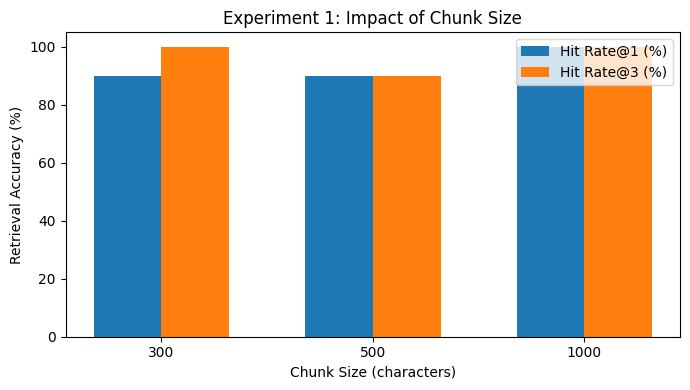

In [8]:
import matplotlib.pyplot as plt

# --- Chart 1: Chunk size ---
sizes = [str(r["chunk_size"]) for r in results_exp1]
hit1 = [r["hit_rate_at_1"] * 100 for r in results_exp1]
hit3 = [r["hit_rate_at_3"] * 100 for r in results_exp1]

x = range(len(sizes))
w = 0.32
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([i - w/2 for i in x], hit1, width=w, label="Hit Rate@1 (%)")
ax.bar([i + w/2 for i in x], hit3, width=w, label="Hit Rate@3 (%)")
ax.set_xticks(list(x)); ax.set_xticklabels(sizes)
ax.set_xlabel("Chunk Size (characters)"); ax.set_ylabel("Retrieval Accuracy (%)")
ax.set_title("Experiment 1: Impact of Chunk Size")
ax.legend()
plt.tight_layout()
plt.show()


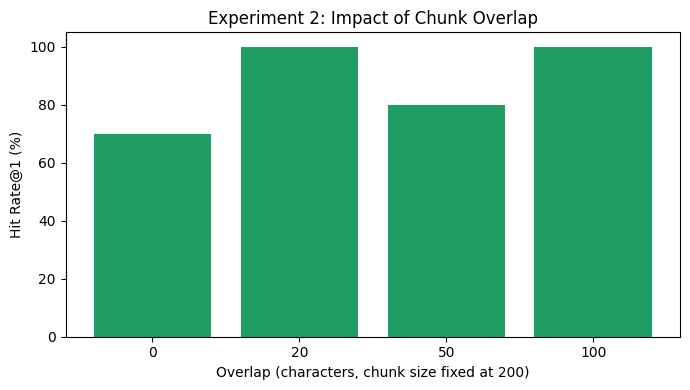

In [9]:
# --- Chart 2: Overlap ---
overlaps = [str(r["overlap"]) for r in results_exp2]
hit1_ov = [r["hit_rate_at_1"] * 100 for r in results_exp2]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(overlaps, hit1_ov, color="#1f9d63")
ax.set_xlabel("Overlap (characters, chunk size fixed at 200)")
ax.set_ylabel("Hit Rate@1 (%)")
ax.set_title("Experiment 2: Impact of Chunk Overlap")
plt.tight_layout()
plt.show()


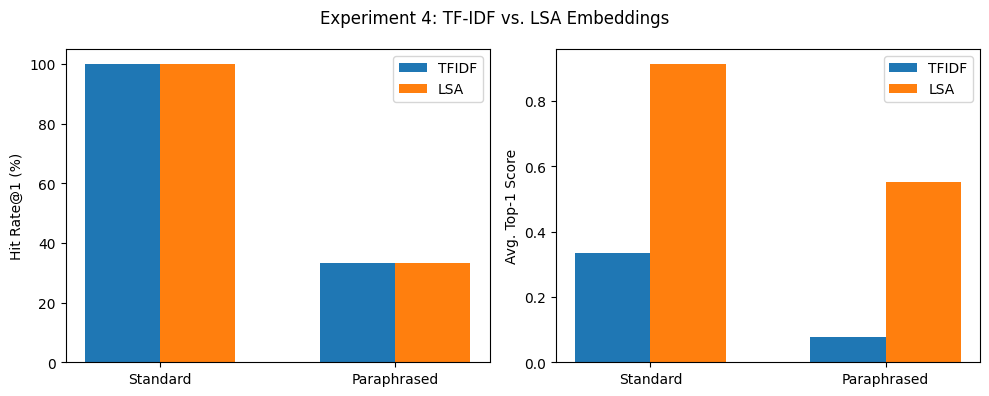

In [10]:
# --- Chart 3: Embedding models ---
import numpy as np

methods = ["tfidf", "lsa"]
qsets = ["standard", "paraphrased"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, metric, ylab in [(axes[0], "hit_rate_at_1", "Hit Rate@1 (%)"), (axes[1], "avg_top1_score", "Avg. Top-1 Score")]:
    mult = 100 if metric == "hit_rate_at_1" else 1
    x = np.arange(len(qsets))
    w = 0.32
    for i, m in enumerate(methods):
        vals = [[r for r in results_exp4 if r["method"] == m and r["query_set"] == qs][0][metric] * mult for qs in qsets]
        ax.bar(x + (i - 0.5) * w, vals, width=w, label=m.upper())
    ax.set_xticks(x); ax.set_xticklabels(["Standard", "Paraphrased"])
    ax.set_ylabel(ylab)
    ax.legend()

fig.suptitle("Experiment 4: TF-IDF vs. LSA Embeddings")
plt.tight_layout()
plt.show()


## 8. Summary of Findings

- **Chunk size:** larger chunks (~1000 chars) gave the highest Hit Rate here but diluted similarity scores; size documents to natural paragraph boundaries.
- **Chunk overlap:** a small overlap (10–20% of chunk size) meaningfully improved accuracy over zero overlap; larger overlap gave no further benefit.
- **Prompt templates:** explicit grounding + a discrete refusal step (Template C) gives the best hallucination control per token spent.
- **Embedding models:** TF-IDF and LSA tie on in-vocabulary queries but both fail equally on paraphrased ones at this small corpus scale — production systems need pretrained neural embeddings (e.g. all-MiniLM-L6-v2) for real paraphrase robustness.
